In [1]:
import sys
import argparse
import math
import random

import inspect
#import scipy.integrate
from scipy import integrate
import numpy as np

import distributions_new as dists
import galacticops_new as go
import beaming_new as beam
import populate

from population import Population
from pulsar import Pulsar
from survey import Survey

#import pygedm

from progressbar import ProgressBar

if sys.version_info[0] < 3:
    import cPickle
else:
    import pickle as cPickle

import pickle

class EvolveException(Exception):
    pass


def generate(ngen,
             surveyList=None,
             savefile='pulsarevo.pkl',
             age_max=1.0E9,
             pDistPars=[2.7, -0.34],
             pDistType='lnorm',          
             bFieldPars=[12.65, 0.55],
             birthVPars=[0.0, 180.],
             siDistPars=[-1.6, 0.35],
             alignModel='orthogonal',
             lumDistType='fk06',
             lumDistPars=[-1.5, 0.5],
             alignTime=None,
             spinModel='fk06',
             beamModel='tm98',
             birthVModel='gaussian',
             electronModel='ne2001_F',
             braking_index=0,
             zscale=0.05,
             duty=5.,
             scindex=-3.86,
             widthModel=None,
             nodeathline=False,
             efficiencycut=None,
             nostdout=False,
             nospiralarms=False,
             keepdead=False):

    pop = Population()

    # set the parameters in the population object

    pop.pmean, pop.psigma = pDistPars
    pop.bmean, pop.bsigma = bFieldPars
    pop.lumDistType = lumDistType

    if lumDistType == 'pow':
        try:
            pop.lummin, pop.lummax, pop.lumpow = \
                lumDistPars[0], lumDistPars[1], lumDistPars[2]
        except ValueError:
            raise EvolveException('Not enough lum distn parameters for "pow"')

    elif lumDistType == 'fk06':
        pop.lumPar1, pop.lumPar2 = lumDistPars[0], lumDistPars[1]
        if len(lumDistPars) == 3:
            pop.lumPar3 = lumDistPars[2]
        else:
            pop.lumPar3 = 0.18

    else:
        pop.lumPar1, pop.lumPar2 = lumDistPars

    pop.simean, pop.sisigma = siDistPars
    pop.birthvmean, pop.birthvsigma = birthVPars

    pop.alignModel = alignModel
    pop.alignTime = alignTime
    pop.spinModel = spinModel
    pop.beamModel = beamModel
    pop.birthVModel = birthVModel
    pop.electronModel = electronModel

    pop.braking_index = braking_index
    pop.deathline = not nodeathline
    pop.nospiralarms = nospiralarms

    pop.zscale = zscale
    

    if widthModel == 'kj07':
        print("\tLoading KJ07 models....")
        kj_p_vals, kj_pdot_vals, kj_dists = beammodels.load_kj2007_models()
        print("\tDone\n")
        widthModel = 'kj07'
    pop.widthModel= widthModel

    

    
    pulsar = Pulsar()
###############################################################################################
 # initial age for pulsar
    ages = np.random.uniform(0.0, age_max, ngen)
        
        #draw an intial period
    pop.pDistType = pDistType
    pop.pmean= pDistPars[0]
    pop.psigma = abs(pDistPars[1])
        
    p0 = get_periods(pop, ngen)

        #intial B field Gauss
    bfield_init = 10 ** np.random.normal( loc=pop.bmean,scale=pop.bsigma, size=ngen)


    

        # aligment angle
    chi, sinchi_init, sinchi, coschi = get_alignment(pop, ages)

        # braking index
    if pop.braking_index == 0:
        braking_index = 2.5 + 0.5 * np.random.random(ngen)
    else:
        braking_index = np.full(ngen, float(pop.braking_index))

        # apply relevant spin down model
    pulsar.dead = False  # pulsar should start alive!

    if pop.spinModel == 'fk06':
        periods, pdot = spindown_fk06_vectorized( p0=p0,age=ages, bfield_init=bfield_init, braking_index=braking_index, sinchi_init=sinchi_init)

        if pop.deathline:
            dead = bhattacharya_deathperiod_92_vectorized(periods, pdot)
        else:
            dead = np.zeros(ngen, dtype=bool)

    elif pop.spinModel == 'tk01':

        periods, pdot = spindown_tk01_vectorized(
                p0=p0,
                age=ages,
                bfield_init=bfield_init
            )
        
        if pop.deathline:
            dead = bhattacharya_deathperiod_92_vectorized(
                    periods,
                    pdot
                )
        else:
            dead = np.zeros(ngen, dtype=bool)
 
    elif pop.spinModel == 'cs06':
        periods, pdot, dead = spindown_cs06_vectorized(p0=p0,bfield_init=bfield_init,age=ages,braking_index=braking_index,coschi=coschi,deathline=pop.deathline
    )

    ###################################################################
        # plough on - only if the pulsar isn't dead!
    #if not pulsar.dead or keepdead:
            # is the pulsar beaming?

        # if not, then skip onto next pulsar
        #if not pulsar.beaming:
           # continue

    valid = (
    (~dead) &                               # Only take pulsars that are NOT physically dead
    (periods >= 1.5) & (periods <= 10000.) & 
    (pdot >= 1e-21) & (pdot <= 1e-11))

    # only take survivors
    periods = periods[valid]
    pdot = pdot[valid]
    ages = ages[valid]
    p0 = p0[valid]
    bfield_init = bfield_init[valid]
    chi = chi[valid]
    sinchi_init = sinchi_init[valid]
    sinchi = sinchi[valid]
    coschi = coschi[valid]

    nvalid = len(periods)

    if nvalid == 0:
        raise "no pulsars alive"

    beaming = pulsar_beaming_new(period=periods,chi=chi,bM=pop.beamModel)
    valid = beaming

     # only take survivors
    periods = periods[valid]
    pdot = pdot[valid]
    ages = ages[valid]
    p0 = p0[valid]
    bfield_init = bfield_init[valid]
    chi = chi[valid]
    sinchi_init = sinchi_init[valid]
    sinchi = sinchi[valid]
    coschi = coschi[valid]

    ngen = len(periods)
    print(ngen,"pulsar alive and beaming")

    if nvalid == 0:
        raise "no pulsars beaming"

    

        #get width width
    if pop.widthModel==None:
        widthModel= None
    widths, width_degree = get_widths(periods,pdot,widthModel,duty,ngen)
       


            # position of the pulsar
    gl, gb, galCoords, r0 = get_galactic_positions(pop, ngen, go, dists, zscale)
            # birthvelocity
    vx, vy, vz = birthVelocity_new(pop, ngen)

            # model the xyz velocity
    galCoords, vx, vy, vz = go.vxyz(galCoords, vx, vy,vz,ages)

# Recalculate Galactic coordinates after motion
    gl, gb = go.xyz_to_lb(galCoords)

# Recalculate Galactocentric radius
    r0 = np.hypot(galCoords[:, 0], galCoords[:, 1])


#################################################################
    if pop.lumDistType == 'lnorm':
            pop.lummean, pop.lumsigma = lumDistPars[0], lumDistPars[1]
    elif  pop.lumDistType =='fk06':
          pop.lummean, pop.lumsigma = \
                 lumDistPars[0], lumDistPars[1]
        
    elif pop.lumDistType == 'log_unif':
        pop.lumlow, pop.lumhigh = \
                lumDistPars[0], lumDistPars[1]
    elif pop.lumDistType == 'log_st':
        try:
            pop.lumlow, pop.lumhigh, pop.lumslope = \
                    lumDistPars[0], lumDistPars[1], lumDistPars[2]
        except ValueError:
            raise PopulateException('Not enough lum distn parameters')
    elif pop.lumDistType == 'd_g':
        pass
    else:
        try:
            pop.lummin, pop.lummax, pop.lumpow = \
                lumDistPars[0], lumDistPars[1], lumDistPars[2]
        except ValueError:
            raise PopulateException('Not enough lum distn parameters')
            
    lum_1400 = get_lum1400(pop,ngen,periods,pdot)
#########################################################################################
    if not nostdout:
        print("\tGenerating evolved pulsars with parameters:")
        print("\t\tngen = {0}".format(ngen))
        print("\t\tUsing electron distn model {0}".format(
                                        pop.electronModel))
        print("\n\t\tPeriod mean, sigma = {0}, {1}".format(
                                                    pop.pmean,
                                                    pop.psigma))
        print("\t\tLuminosity mean, sigma = {0}, {1}".format(
                                                    pop.lummean,
                                                    pop.lumsigma))
        print("\t\tSpectral index mean, sigma = {0}, {1}".format(
                                                    pop.simean,
                                                    pop.sisigma))
        print("\t\tGalactic z scale height = {0} kpc".format(
                                                    pop.zscale))
        if widthModel is None:
            print("\t\tWidth {0}% ".format(duty))
        else:
            print("\t\tUsing Karastergiou & Johnston beam width model")

        # set up progress bar for fun :)
        prog = ProgressBar(min_value=0,
                           max_value=ngen,
                           width=65,
                           mode='dynamic')
###############################################################################################
            # apply efficiency cutoff
    if efficiencycut is not None:
        if pulsar.efficiency() > efficiencycut:
             pulsar.dead = True
                #if not keepdead:
                    # continue
####################################################################################
            # spectral index
    spindex = np.random.normal(pop.simean,pop.sisigma,size=ngen)

    
    rsun = 8.5
    dtrue = np.sqrt(galCoords[:, 0]**2+ (galCoords[:, 1] - rsun)**2+ galCoords[:, 2]**2)

    dm=[]
    tau_sc=[]
    if electronModel not in ['ne2001', 'lmt85','ymw16','ne2025','ne2001_F']:
        print("Unsupported electron model: {0}".format(electronModel))
            
        
            # then calc DM  using fortran libs
    if pop.electronModel == 'ne2001':
        for i in range(ngen):
            DM, tau =pygedm.dist_to_dm( gl[i], gb[i],dtrue[i]*1000, method='ne2001') #takes distance in pc
            dm.append(DM)
            tau_sc.append(tau)
    elif pop.electronModel == 'ne2001_F':
        for i in range(ngen):
             DM = go.ne2001_dist_to_dm(dtrue[i], gl[i], gb[i])
             dm.append(DM)
             #tau_sc.append(tau_sc)
    elif pop.electronModel == 'lmt85':
        for i in range(ngen):
             dm1, tau = go.lmt85_dist_to_dm(dtrue[i], gl[i], gb[i])
             dm.append(dm1)
             tau_sc.append(tau)
    elif pop.electronModel == 'ymw16':
        for i in range(ngen):
                   #gl, gb, dist
             DM, tau = pygedm.dist_to_dm( gl[i], gb[i],dtrue[i]*1000, method='ymw16')
             dm.append(DM)
             tau_sc.append(tau)
    elif pop.electronModel =='ne2025':
        for i in range(ngen):
             gl, gb, dist
             DM, tau = pygedm.dist_to_dm( gl[i], gb[i],dtrue[i]*1000, method='ne2025')
             dm.append(DM)
             tau_sc.append(tau)
             
    #####################################################################################################################################

            #scattering
    scindex_arr = np.full(ngen, scindex)
    if pop.electronModel == 'ne2001_F':   
        tau_sc = np.array([
            go.scatter_bhat(dm_i, scindex)
            for dm_i in dm])
                

    

    # save list of arguments into the pop
    #try:
    #    argspec = inspect.getargspec(generate)
    #    key_values = [(arg, locals()[arg]) for arg in argspec.args]
    #    pop.arguments = {key: value for (key, value) in key_values}
    #except SyntaxError:
     #   pass

    pulsars = []
    pop.population = []
    

    pulsars = []
    for (age, p0_i, period, B, chi_i, sin0, sin_i, cos_i,
     n, pdot_i, dead_i, lum_i, spindex_i,
     gl_i, gb_i, galCoords_i, r0_i, dtrue_i,
     dm_i, tau_sc_i, beaming_i,
     vx_i, vy_i, vz_i, widths_i, width_deg_i,) in zip(
        ages,
        p0,
        periods,
        bfield_init,
        chi,
        sinchi_init,
        sinchi,
        coschi,
        braking_index,
        pdot,
        dead,
        lum_1400,
        spindex,
        gl,
        gb,
        galCoords,
        r0,
        dtrue,
        dm,
        tau_sc,
        beaming,
        vx,
        vy,
        vz,
        widths,         # 3. Added widths array to zip
        width_degree):

        p = Pulsar()
    
        p.age = age
        p.p0 = p0_i
        p.period = period
        p.pdot = pdot_i
        p.bfield_init = B
        p.braking_index = n
    
        p.chi = chi_i
        p.sinchi_init = sin0
        p.sinchi = sin_i
        p.coschi = cos_i
    
        p.dead = dead_i
        p.beaming = beaming_i
    
        p.lum_1400 = lum_i
        p.lum_inj_mu = lum_i
        p.spindex = spindex_i
    
        p.gl = gl_i
        p.gb = gb_i
        p.galCoords = galCoords_i
        p.r0 = r0_i
        p.dtrue = dtrue_i
    
        p.vx = vx_i
        p.vy = vy_i
        p.vz = vz_i
    
        p.dm = dm_i
        p.tau_sc = tau_sc_i
        p.widths=widths_i
        p.width_degree=width_deg_i
        
    
        pulsars.append(p)
        pop.population.append(p)

    

    # save
    with open(savefile, "wb") as f:
        pickle.dump(pop, f)

    print("Saved population as", savefile)
    
    return pulsars

In [2]:
def birthVelocity(pulsar, pop):
    """ Get a birth veolocity for the pulsar"""

    bvM = pop.birthVModel
    mean = pop.birthvmean
    sigma = pop.birthvsigma
    if bvM == 'gaussian':
        pulsar.vx = random.gauss(mean, sigma)
        pulsar.vy = random.gauss(mean, sigma)
        pulsar.vz = random.gauss(mean, sigma)
    elif bvM == 'exp':
        pulsar.vx = dists.draw_double_sided_exp(sigma, origin=mean)
        pulsar.vy = dists.draw_double_sided_exp(sigma, origin=mean)
        pulsar.vz = dists.draw_double_sided_exp(sigma, origin=mean)
    else:
        raise EvolveException('Invalid velocity model selected')


def galacticDistribute(pulsar, pop):
    """ select a galactic position - spiral arms on or off?"""
    if not pop.nospiralarms:
        # using spiral arms
        r0 = go.ykr()
        x, y = go.spiralize(r0)
    else:
        # distribute randomly in x-y plane
        x = -20. + random.random()*40.
        y = -20. + random.random()*40.

    # calculate z and r0
    z = dists.draw_double_sided_exp(pop.zscale)
    pulsar.galCoords = (x, y, z)
    pulsar.r0 = math.sqrt(x**2 + y**2)


def alignpulsar(pulsar, pop):
    """
    Pick an alignment angle for pulsar, depending on model chosen

    """

    # need to be careful to use chi in degrees, but
    # consistently remember to take the sins/cosines of radians
    if pop.alignModel == 'orthogonal':
        pulsar.chi = 90.0
        pulsar.sinchi_init = 1.0
        pulsar.sinchi = pulsar.sinchi_init
        pulsar.coschi = 0.

    elif pop.alignModel == 'random':
        chi = math.acos(random.random())  # in radians

        pulsar.chi = math.degrees(chi)  # -> degrees
        pulsar.sinchi_init = math.sin(math.radians(chi))
        pulsar.sinchi = pulsar.sinchi_init
        pulsar.coschi = math.cos(math.radians(chi))

    elif pop.alignModel == 'rand45':
        pulsar.coschi = random.random() * (1.0 - math.sqrt(0.5)) \
                            + math.sqrt(0.5)
        pulsar.chi = math.degrees(math.acos(pulsar.coschi))
        pulsar.sinchi_init = math.sin(math.radians(pulsar.chi))
        pulsar.sinchi = pulsar.sinchi_init

    elif pop.alignModel == 'wj08':
        # check an alignment timescale has been provided
        if pop.alignTime is None:
            raise EvolveException('Align timescale needed for WJ08 model')

        # weltevrede & johnston alignment model
        pulsar.coschi = random.random()
        chi = math.degrees(math.acos(pulsar.coschi))
        pulsar.sinchi_init = math.sin(math.radians(chi))
        pulsar.sinchi = pulsar.sinchi_init * math.exp(-pulsar.age/pop.alignTime)
        pulsar.chi = math.degrees(math.asin(pulsar.sinchi))

    else:
        raise EvolveException('Invalid alignment model: {0}'.format(aM))

    # more models to add here, but it'll do for now


def pulsar_beaming(pulsar, bM):
    """
    Work out if the pulsar is beaming --- model-dependent
    """

    # Tauris & Manchester beaming model (default)
    if bM == 'tm98':
        fraction = beammodels.tm98_fraction(pulsar)
    # more models to add here!
    elif bM == 'none':
        fraction = 1.0
    elif bM == 'const':
        fraction = 0.2
    elif bM == 'wj08':
        fraction = beammodels.wj08_fraction(pulsar)
    else:
        raise EvolveException('Invalid beaming model: {0}'.format(bM))

    if random.random() < fraction:
        pulsar.beaming = True
    else:
        pulsar.beaming = False


def luminosity_fk06_new(
    period,
    pdot,
    alpha=-1.5,
    beta=0.5,
    gamma=0.18
):
    """
    Vectorized Faucher-Giguère & Kaspi (2006) luminosity model.

    Parameters
    ----------
    period : array_like
        Pulsar periods in ms.

    pdot : array_like
        Pulsar period derivatives.

    alpha : float
        Period exponent.

    beta : float
        Pdot exponent.

    gamma : float
        Normalization.

    Returns
    -------
    lum_1400 : ndarray
        1400 MHz luminosities.
    """

    period = np.asarray(period, dtype=float)
    pdot = np.asarray(pdot, dtype=float)

    # Intrinsic luminosity scatter
    delta_l = np.random.normal(
        loc=0.0,
        scale=0.8,
        size=period.shape
    )

    logL = (
        np.log10(gamma)
        + alpha * np.log10(period / 1000.0)
        + beta * np.log10(pdot * 1.0e15)
        + delta_l
    )

    return 10.0 ** logL


def spindown_fk06(pulsar):
    """ Spindown model from Faucher-Giguere & Kaspi 2006 """
    # k is a constant from the FK06 paper in cgs units
    k = 9.768E-40 
    kprime = k * pulsar.bfield_init**2 
    
    # 1. Calculate P(t) in SECONDS, then store it as MILLISECONDS for the object
    period_s = _p_of_t_fk06(pulsar, kprime)
    pulsar.period = period_s * 1000
    
    # 2. Calculate pdot using the standard function
    pulsar.pdot = _pdot_fk06(pulsar, kprime)


def _p_of_t_fk06(pulsar, kprime):
    """ Equation 6 - Ridley & Lorimer 2010 """
    index_term = pulsar.braking_index - 1.0
    age_s = pulsar.age * 3.15569e7  # Convert years to seconds
    
    # CRITICAL FIX: Convert p0 from milliseconds to seconds here
    p0_s = pulsar.p0 / 1000.0
    
    # Calculate brackets using purely standard SI/CGS time units (seconds)
    brackets = p0_s**(index_term) + index_term * kprime * age_s * pulsar.sinchi_init**2
    
    return brackets**(1.0 / index_term)


def _pdot_fk06(pulsar, kprime):
    """ Equation 3 - Ridley & Lorimer 2010 """
    index_term = 2.0 - pulsar.braking_index
    
    # This step is already correct: converts the stored ms period back to seconds
    period_s = pulsar.period / 1000.0
    
    return kprime * pulsar.sinchi_init**2 * period_s**(index_term)


def spindown_cs06(pulsar, pop):
    """
    Equations 9 and 10 in Ridley & Lorimer -
    due to Contopoulos & Spitkovsky 2006
    """
    # this is equation 10
    index = (2.0 / (pulsar.braking_index + 1.0))
    pdeath = (0.81 * pulsar.bfield_init / 1.0E12 / pulsar.p0) ** index
    # convert to milliseconds
    pdeath *= 1000.

    # this method needs integrals.
    # converting the qsimp (fortran) to using scipy.integrate package
    # tested and they should give same output
    lower_limit = pulsar.p0*1000.
    upper_limit = 1.0E5
    const_of_integration = pulsar.coschi**2.0 / pdeath

    min_value = 1.0E24
    min_p = pulsar.p0*1000.

    index = pulsar.braking_index - 3.0
    temp_const = 3.3E-40*pulsar.bfield_init**2 * (pulsar.p0*1000.)**index \
                        * pulsar.age * 365.25 * 24. * 3.6E9  # 3.15569e7

    # do the integral
    result = scipy.integrate.quad(_cs06_poft,
                                  lower_limit,
                                  pdeath,
                                  args=(const_of_integration,
                                        pulsar.braking_index)
                                  )[0]

    if result < temp_const or result > 1.0E14:
        pulsar.period = 1.0E6
    else:
        looparray = np.arange(lower_limit, upper_limit+1)
        count = 0
        for m in looparray:
            count += 1
            result = scipy.integrate.quad(_cs06_poft,
                                          lower_limit,
                                          pdeath,
                                          args=(const_of_integration,
                                                pulsar.braking_index)
                                          )[0]
            if result > 1.0E14:
                pulsar.period = 1.0E6
                break

            tempmin = math.fabs(result - temp_const)

            if tempmin <= min_value:
                min_value = tempmin
                min_p = m
            else:
                pulsar.period = min_p
                break

            # end of loop
        else:
            pulsar.period = 1.0E6

    # see whether the pulsar should be dead
    # (are we using deathline? Is pulsar above it?)
    if pulsar.period > pdeath and pop.deathline:
        pulsar.dead = True
    else:
        pulsar.dead = False
        index = 2.0-pulsar.braking_index
        pulsar.pdot = 3.3E-40 * pulsar.bfield_init**2.0 * (1./pulsar.p0)\
            * (pulsar.period / (pulsar.p0*1000.))**index * \
            (1. - const_of_integration * pulsar.period)


def _cs06_poft(x, a, n):
    return x**(n-2.0) / (1.0-a*x)




# Defining a new spindown model based evolution of magnetic field and alignment
def spindown_tk01(pulsar):

  tau_a = 1e7*3.15569e7  # alignment timescale in seconds
  tau_b = 4e6*3.15569e7  # field decay timescale
  tau_d = tau_b*tau_a/(tau_b + tau_a)
  k = 9.768E-40 # cgs again
  age_s = pulsar.age*3.15569e7  # in seconds
  pulsar.period = (np.sqrt(pow(pulsar.bfield_init,2)*k*tau_d*(1-np.exp(-2*age_s/tau_d)) + pow(pulsar.p0,2)))*1000
  pulsar.pdot = np.exp(-2*age_s/tau_d)*pow(pulsar.bfield_init,2)*k*1000/pulsar.period



def bhattacharya_deathperiod_92(pulsar):
    """
    Eq 8 in Ridley & Lorimer - but it's the deathline from
    Bhattacharya et al 1992
    """
    # deathline described by
    # B/P^2 = 0.17E12 G s^-2

    # magnetic field = 3.2e19 * sqrt( P Pdot)
    B = 3.2E19 * math.sqrt(pulsar.period * pulsar.pdot / 1000.)

    if B/(pulsar.period/1000.)**2 < 0.17E12:
        pulsar.dead = True


def get_periods(pop, ngen):
    
    if pop.pDistType == 'lnorm':
        periods = dists.drawlnorm(pop.pmean, pop.psigma, ngen)

    elif pop.pDistType == 'unif':
        periods = np.random.uniform(
            pop.pmean - pop.psigma,
            pop.pmean + pop.psigma,
            size=ngen
        )

    elif pop.pDistType == 'norm': 
    
        raw_periods = np.random.normal(pop.pmean, pop.psigma, size=ngen) 
        periods = np.maximum(raw_periods, 0.1)
    
    elif pop.pDistType == 'cc97':
        periods = np.array([_cc97() for _ in range(ngen)])

    elif pop.pDistType == 'gamma':
        #impliment good values for shape,scale
        shape, scale = pop.pmean, pop.psigma # mean and width
        periods = np.random.gamma(shape,scale,ngen)
        
    elif pop.pDistType == 'd_g':
        Pbin_num = dists.draw1d(
            dgf_pop_load['pHist'],
            size=ngen
        )
        Pmin = dgf_pop_load['pBins'][0]
        Pmax = dgf_pop_load['pBins'][-1]

        periods = (
            Pmin
            + (Pmax - Pmin)
            * (Pbin_num + np.random.random(size=ngen))
            / len(dgf_pop_load['pHist'])
        )

    elif pop.pDistType == 'lorimer12':
        periods = np.array(
            [_lorimer2012_msp_periods() for _ in range(ngen)]
        )
    
        
    elif pDistType == "drl15":
        L_p0 = np.random.lognormal(mean=pop.pmean,sigma=pop.psigma,size=ngen)
        periods = np.exp(L_p0) / 1000.0

    else:
        raise ValueError(f"Unknown pDistType: {pop.pDistType}")

    return periods


def get_alignment(pop, age):
    N = len(age)

    if pop.alignModel == "orthogonal":
        chi = np.full(N, 90.0)
        sinchi_init = np.ones(N)
        sinchi = sinchi_init.copy()
        coschi = np.zeros(N)

    elif pop.alignModel == "random":
        chi_rad = np.arccos(np.random.random(N))

        chi = np.degrees(chi_rad)
        sinchi_init = np.sin(chi_rad)
        sinchi = sinchi_init.copy()
        coschi = np.cos(chi_rad)

    elif pop.alignModel == "rand45":
        coschi = (
            np.random.random(N) * (1.0 - np.sqrt(0.5))
            + np.sqrt(0.5)
        )

        chi_rad = np.arccos(coschi)
        chi = np.degrees(chi_rad)
        sinchi_init = np.sin(chi_rad)
        sinchi = sinchi_init.copy()

    elif pop.alignModel == "wj08":
        if pop.alignTime is None:
            raise EvolveException(
                "Align timescale needed for WJ08 model"
            )

        coschi = np.random.random(N)
        chi_rad = np.arccos(coschi)

        sinchi_init = np.sin(chi_rad)
        sinchi = sinchi_init * np.exp(-age / pop.alignTime)
        chi = np.degrees(np.arcsin(sinchi))

    else:
        raise EvolveException(
            f"Invalid alignment model: {pop.alignModel}"
        )

    return chi, sinchi_init, sinchi, coschi

In [3]:


def spindown_fk06_vectorized(p0, age, bfield_init, braking_index, sinchi_init):
    """
    Vectorized Faucher-Giguere & Kaspi (2006) spindown model.

    Parameters
    ----------
    p0 : array
        Initial period in MILLISECONDS .
    age : array
        Initial age in years.
    bfield_init : array
        Initial magnetic field in Gauss.
    braking_index : array
        Braking index.
    sinchi_init : array
        Initial sin(alignment angle).

    Returns
    -------
    period : array
        Current period in milliseconds.
    pdot : array
        Current period derivative in s/s.
    """
    k = 9.768e-40
    kprime = k * bfield_init**2
    
    # CRITICAL FIX: Convert p0 from milliseconds to seconds for the CGS physics constant
    #print(p0)
    p0_s = p0 / 1000.0
    
    index_term = braking_index - 1.0
    age_s = age * 3.15569e7  # Convert years to seconds
    
    # Equation 6 (using the corrected p0_s in seconds)
    brackets = (
        p0_s**index_term + 
        index_term * kprime * age_s * sinchi_init**2
    )
    period_s = brackets**(1.0 / index_term)
    
    # Convert output back to milliseconds to match your tracking loop
    period = period_s * 1000.0
    
    # Equation 3
    index_term_pdot = 2.0 - braking_index
    pdot = (kprime * sinchi_init**2 * period_s**index_term_pdot)
    #print(period,pdot)
    
    return period, pdot


from scipy.special import hyp2f1


def spindown_cs06_vectorized(p0, bfield_init, age, braking_index,
                             coschi, deathline=True):
    """
    Vectorized Contopoulos & Spitkovsky (2006) spindown.

    Parameters
    ----------
    p0 : array_like
        Initial period [seconds].
    bfield_init : array_like
        Initial magnetic field [G].
    age : array_like
        Age [yr].
    braking_index : array_like
        Braking index.
    coschi : array_like
        cos(obliquity).
    deathline : bool
        Whether to apply the death line.

    Returns
    -------
    period : ndarray
        Final period [ms].
    pdot : ndarray
        Period derivative.
    dead : ndarray
        Boolean death flag.
    """

    p0 = np.asarray(p0, dtype=np.float64)
    bfield_init = np.asarray(bfield_init, dtype=np.float64)
    age = np.asarray(age, dtype=np.float64)
    n = np.asarray(braking_index, dtype=np.float64)
    coschi = np.asarray(coschi, dtype=np.float64)

    # ------------------------------------------------------------
    # Equation 10
    # ------------------------------------------------------------
    index = 2.0 / (n + 1.0)

    pdeath = (
        0.81
        * bfield_init / 1.0e12
        / p0
    ) ** index

    # seconds -> milliseconds
    pdeath *= 1000.0

    # ------------------------------------------------------------
    # Integration constants
    # ------------------------------------------------------------
    lower = p0 * 1000.0

    a = coschi**2 / pdeath

    temp_const = (
        3.3e-40
        * bfield_init**2
        * (p0 * 1000.0) ** (n - 3.0)
        * age
        * 365.25
        * 24.0
        * 3.6e9
    )

    # ------------------------------------------------------------
    # Analytical integral
    #
    # integral x^(n-2)/(1-a*x) dx
    #
    # = x^(n-1)/(n-1) *
    #   hyp2f1(1,n-1;n;a*x)
    # ------------------------------------------------------------

    k = n - 1.0

    def primitive(x):
        return (
            x**k / k
            * hyp2f1(1.0, k, k + 1.0, a * x)
        )

    result = primitive(pdeath) - primitive(lower)

    # ------------------------------------------------------------
    # Determine period
    # ------------------------------------------------------------
    period = np.full_like(p0, 1.0e6)

    valid = (
        (result >= temp_const)
        & (result <= 1.0e14)
    )

    # The original loop appears to intend to find the period
    # where the integral matches temp_const.
    #
    # If the intended integral is from lower -> m, solve for m.
    #
    # We can do this with a vectorized bisection instead of
    # looping over every millisecond.
    # ------------------------------------------------------------

    lo = lower.copy()
    hi = pdeath.copy()

    active = valid & (pdeath > lower)

    for _ in range(40):
        mid = 0.5 * (lo + hi)

        integral_mid = primitive(mid) - primitive(lower)

        too_small = integral_mid < temp_const

        lo = np.where(active & too_small, mid, lo)
        hi = np.where(active & ~too_small, mid, hi)

    period = np.where(
        active,
        0.5 * (lo + hi),
        1.0e6
    )

    # ------------------------------------------------------------
    # Death line
    # ------------------------------------------------------------
    dead = period > pdeath if deathline else np.zeros_like(period, dtype=bool)

    # ------------------------------------------------------------
    # Pdot
    # ------------------------------------------------------------
    index = 2.0 - n

    pdot = np.zeros_like(period)

    alive = ~dead

    pdot[alive] = (
        3.3e-40
        * bfield_init[alive]**2
        * (1.0 / p0[alive])
        * (
            period[alive]
            / (p0[alive] * 1000.0)
        ) ** index[alive]
        * (
            1.0
            - a[alive] * period[alive]
        )
    )

    return period, pdot, dead


def bhattacharya_deathperiod_92_vectorized(period, pdot):
    """
    Vectorized Bhattacharya et al. (1992) deathline.

    Parameters
    ----------
    period : array
        Period in milliseconds.
    pdot : array
        Period derivative in s/s.

    Returns
    -------
    dead : boolean array
        True for pulsars below the deathline.
    """

    period_s = period / 1000.0

    B = 3.2e19 * np.sqrt(period_s * pdot)
    #print((B / (period_s**2)))
    dead = (B / (period_s**2)) < 0.17e12

    return dead



def spindown_tk01_vectorized(p0, age, bfield_init):
    """
    Vectorized TK01 spin-down model (Tauris & Konar 2001).

    Parameters
    ----------
    p0 : array
        Initial period in MILLISECONDS (matching your lnorm distribution).
    age : array
        Pulsar age in years.
    bfield_init : array
        Initial magnetic field in Gauss.

    Returns
    -------
    period : array
        Current period in milliseconds.
    pdot : array
        Period derivative in s/s.
    """
    # 1. Timescales converted from years to seconds
    tau_a = 1e7 * 3.15569e7
    tau_b = 4e6 * 3.15569e7
    tau_d = tau_b * tau_a / (tau_b + tau_a)

    # FK06 Constant (CGS)
    k = 9.768e-40

    # 2. CRITICAL UNIT FIX: Convert initial period from ms to seconds
    p0_s = p0 / 1000.0
    
    # Age: years -> seconds
    age_s = age * 3.15569e7

    # 3. Calculate current period in seconds
    period_s = np.sqrt(
        bfield_init**2 * k * tau_d * (1.0 - np.exp(-2.0 * age_s / tau_d)) + p0_s**2
    )

    # Convert to milliseconds for your loop tracking compatibility
    period = period_s * 1000.0

    # 4. CRITICAL PHYSICS FIX: Calculate pdot (s/s) using period in SECONDS
    pdot = (bfield_init**2 * k * np.exp(-2.0 * age_s / tau_d)) / period_s

    return period, pdot



def get_widths(periods, pdot, widthModel, duty, ngen):

    if widthModel is None:

        width_log = np.log10(
            (float(duty) / 100.0) * periods**0.9
        )

        widths = 10**np.random.normal(
            width_log,
            0.3,
            size=ngen
        )

    elif widthModel == 'kj07':

        logp = np.log10(periods)
        logpdot = np.log10(pdot)

        # Find closest P grid point for every pulsar
        p_idx = np.abs(
            kj_p_vals[:, None] - logp[None, :]
        ).argmin(axis=0)

        # Find closest Pdot grid point for every pulsar
        pd_idx = np.abs(
            kj_pdot_vals[:, None] - logpdot[None, :]
        ).argmin(axis=0)

        # Draw from the appropriate distribution
        widths = np.zeros(ngen)

        for i in range(ngen):
            dist = kj_dists[p_idx[i]][pd_idx[i]][2]

            if len(dist) > 0:
                widths[i] = np.random.choice(dist)

    else:
        raise ValueError(f"Undefined width model: {widthModel}")

    # Convert width to degrees
    width_degree = np.zeros(ngen)

    valid = widths != 0.0

    width_degree[valid] = (
        360.0 * widths[valid] / periods[valid]
    )

    return widths, width_degree

def get_lum1400(pop,ngen,periods,pdot):
    
    if pop.lumDistType == 'lnorm':
        lum_1400 = dists.drawlnorm(pop.lummean, pop.lumsigma, ngen)

    elif pop.lumDistType == 'pow':
        lum_1400 = dists.powerlaw(pop.lummin,pop.lummax,pop.lumpow,ngen)

    elif pop.lumDistType == 'fk06':
        lum_1400 = luminosity_fk06_new(periods,pdot)

   #this one doesn't seem to be in the dists
    elif pop.lumDistType == 'log_st':
        log_lum = pop.lumlow + dists.st_line(
            pop.lumslope,
            pop.lumhigh - pop.lumlow,
            size=ngen
        )
        lum_1400 = 10.0 ** log_lum

    elif pop.lumDistType == 'log_unif':
        lum_1400 = 10.0 ** dists.uniform(pop.lumlow,pop.lumhigh,ngen)

    elif pop.lumDistType == 'd_g':
        lHist = dgf_pop_load['lHist']
        lBins = dgf_pop_load['lBins']

        lbin_num = dists.draw1d(lHist, size=ngen)
        lmin, lmax = lBins[0], lBins[-1]

        logl = lmin + (lmax - lmin) * (
            lbin_num + np.random.random(size=ngen)
        ) / len(lHist)

        lum_1400 = 10.0 ** logl
        
    return lum_1400

def get_galactic_positions(pop, N, go, dists, zscale):

    gl = np.zeros(N)
    gb = np.zeros(N)
    galCoords = np.zeros((N, 3))
    r0 = np.zeros(N)

    # -------------------------
    # Radial distribution
    # -------------------------

    if pop.radialDistType == 'isotropic':

        u = np.random.random(N)
        gb = np.degrees(np.arcsin(u))
        signs = np.where(np.random.random(N) < 0.5, -1.0, 1.0)
        gb *= signs

        gl = np.random.random(N) * 360.0

        # pretend distance = 1 kpc
        x,y,z = go.lb_to_xyz(gl, gb, np.ones(N))
       
    
    elif pop.radialDistType == 'slab':

        galCoords = go.slabdist(N)
        gl, gb = go.xyz_to_lb(galCoords)

    elif pop.radialDistType == 'disk':

        galCoords = go.diskdist(N)
        gl, gb = go.xyz_to_lb(galCoords)

    else:

        # -------- r0 models --------
        if pop.radialDistType == 'lfl06':
            r0 = go.lfl06(N)

        elif pop.radialDistType == 'gamma':
            fit_alpha = 1050.312227
            fit_loc   = -8.12315263841
            fit_beta  = 0.00756010693478

            r0 = 8.5 * stats.gamma.rvs(
                fit_alpha,
                loc=fit_loc,
                scale=fit_beta,
                size=N
            ) + 8.5

        elif pop.radialDistType == 'd_g':
            Rbin_num = dists.draw1d(dgf_pop_load['RHist'], size=N)

            Rmin = dgf_pop_load['RBins'][0]
            Rmax = dgf_pop_load['RBins'][-1]

            r0 = Rmin + (Rmax - Rmin) * (
                (Rbin_num + np.random.random(N)) /
                len(dgf_pop_load['RHist'])
            )

        elif pop.radialDistType == 'yk04':
            r0 = go.ykr(N)

        elif pop.radialDistType == 'unif':
            r0 = np.random.uniform(0, 12.3, N)

        elif pop.radialDistType == 'gauss':
            r0 = np.random.normal(0., pop.rsigma, N)

        # -------- z distribution --------
        if pop.zscaleType == 'exp':
            zheight = go._double_sided_exp(zscale, size=N)

        elif pop.zscaleType == 'unif':
            zheight = np.random.uniform(
                -1.06489765758,
                 1.91849552866,
                 N
            )

        elif pop.zscaleType == 'd_g':
            zbin_num = dists.draw1d(dgf_pop_load['ZHist'], size=N)

            logzmin = dgf_pop_load['ZBins'][0]
            logzmax = dgf_pop_load['ZBins'][-1]

            logz = logzmin + (logzmax - logzmin) * (
                (zbin_num + np.random.random(N)) /
                len(dgf_pop_load['ZHist'])
            )

            zheight = logz

        else:
            zheight = np.random.normal(0., zscale, N)

        # -------- convert to xyz --------
        # assume cylindrical: (r0, phi, zheight)

        phi = np.random.uniform(0, 2*np.pi, N)

        x = r0 * np.cos(phi)
        y = r0 * np.sin(phi)
        z = zheight

        galCoords = np.column_stack((x, y, z))

        gl, gb = go.xyz_to_lb(galCoords)

    return gl, gb, galCoords, r0





def get_galactic_positions(pop, N, go, dists, zscale):

    # ============================================================
    # Spiral-arm model
    # ============================================================

    if not pop.nospiralarms:

        r0 = go.ykr(N)

        x, y = go.spiralize(r0)

        z = go._double_sided_exp(
            zscale,
            size=N
        )

        galCoords = np.column_stack((x, y, z))

        gl, gb = go.xyz_to_lb(galCoords)

        return gl, gb, galCoords, r0

    # ============================================================
    # No spiral arms
    # ============================================================

    if pop.radialDistType == 'isotropic':

        u = np.random.random(N)

        gb = np.degrees(np.arcsin(u))

        signs = np.where(
            np.random.random(N) < 0.5,
            -1.0,
            1.0
        )

        gb *= signs

        gl = np.random.random(N) * 360.0

        # Assume distance = 1 kpc
        x, y, z = go.lb_to_xyz(
            gl,
            gb,
            np.ones(N)
        )

        galCoords = np.column_stack((x, y, z))

        r0 = np.sqrt(x**2 + y**2)

        return gl, gb, galCoords, r0

    # ============================================================
    # Direct spatial distributions
    # ============================================================

    if pop.radialDistType == 'slab':

        galCoords = go.slabdist(N)

        gl, gb = go.xyz_to_lb(galCoords)

        r0 = np.sqrt(
            galCoords[:, 0]**2 +
            galCoords[:, 1]**2
        )

        return gl, gb, galCoords, r0

    if pop.radialDistType == 'disk':

        galCoords = go.diskdist(N)

        gl, gb = go.xyz_to_lb(galCoords)

        r0 = np.sqrt(
            galCoords[:, 0]**2 +
            galCoords[:, 1]**2
        )

        return gl, gb, galCoords, r0

    # ============================================================
    # Radial distribution
    # ============================================================

    if pop.radialDistType == 'lfl06':

        r0 = go.lfl06(N)

    elif pop.radialDistType == 'gamma':

        fit_alpha = 1050.312227
        fit_loc = -8.12315263841
        fit_beta = 0.00756010693478

        r0 = (
            8.5
            * stats.gamma.rvs(
                fit_alpha,
                loc=fit_loc,
                scale=fit_beta,
                size=N
            )
            + 8.5
        )

    elif pop.radialDistType == 'd_g':

        Rbin_num = dists.draw1d(
            dgf_pop_load['RHist'],
            size=N
        )

        Rmin = dgf_pop_load['RBins'][0]
        Rmax = dgf_pop_load['RBins'][-1]

        r0 = Rmin + (Rmax - Rmin) * (
            (Rbin_num + np.random.random(N))
            / len(dgf_pop_load['RHist'])
        )

    elif pop.radialDistType == 'yk04':

        r0 = go.ykr(N)

    elif pop.radialDistType == 'unif':

        r0 = np.random.uniform(
            0.0,
            12.3,
            N
        )

    elif pop.radialDistType == 'gauss':

        r0 = np.random.normal(
            0.0,
            pop.rsigma,
            N
        )

    else:

        raise ValueError(
            f"Unknown radial distribution: "
            f"{pop.radialDistType}"
        )

    # ============================================================
    # z distribution
    # ============================================================

    if pop.zscaleType == 'exp':

        zheight = go._double_sided_exp(
            zscale,
            size=N
        )

    elif pop.zscaleType == 'unif':

        zheight = np.random.uniform(
            -1.06489765758,
            1.91849552866,
            N
        )

    elif pop.zscaleType == 'd_g':

        zbin_num = dists.draw1d(
            dgf_pop_load['ZHist'],
            size=N
        )

        logzmin = dgf_pop_load['ZBins'][0]
        logzmax = dgf_pop_load['ZBins'][-1]

        logz = logzmin + (
            logzmax - logzmin
        ) * (
            (zbin_num + np.random.random(N))
            / len(dgf_pop_load['ZHist'])
        )

        zheight = logz

    else:

        zheight = np.random.normal(
            0.0,
            zscale,
            N
        )

    # ============================================================
    # Convert cylindrical coordinates to Cartesian
    # ============================================================

    phi = np.random.uniform(
        0.0,
        2.0 * np.pi,
        N
    )

    x = r0 * np.cos(phi)
    y = r0 * np.sin(phi)
    z = zheight

    galCoords = np.column_stack(
        (x, y, z)
    )

    gl, gb = go.xyz_to_lb(galCoords)

    return gl, gb, galCoords, r0

def birthVelocity_new(pop, N):
    """Generate birth velocities for N pulsars."""

    bvM = pop.birthVModel
    mean = pop.birthvmean
    sigma = pop.birthvsigma

    if bvM == 'gaussian':

        vx = np.random.normal(
            mean,
            sigma,
            size=N
        )

        vy = np.random.normal(
            mean,
            sigma,
            size=N
        )

        vz = np.random.normal(
            mean,
            sigma,
            size=N
        )

    elif bvM == 'exp':

        vx = go._double_sided_exp(
            sigma,
            origin=mean,
            size=N
        )

        vy = go._double_sided_exp(
            sigma,
            origin=mean,
            size=N
        )

        vz = go._double_sided_exp(
            sigma,
            origin=mean,
            size=N
        )

    else:

        raise EvolveException(
            'Invalid velocity model selected'
        )

    return vx, vy, vz

def pulsar_beaming_new(period, chi, bM):
    """
    Determine which pulsars are beaming.

    Parameters
    ----------
    period : ndarray
        Pulsar periods in seconds.

    chi : ndarray
        Magnetic inclination angles in degrees.

    bM : str
        Beaming model.

    Returns
    -------
    beaming : ndarray of bool
        True for pulsars whose beams intersect Earth.
    """

    if bM == 'tm98':
        fraction = beam.tm98_fraction(period)

    elif bM == 'none':
        fraction = 1.0

    elif bM == 'const':
        fraction = 0.2

    elif bM == 'wj08':
        fraction = beam.wj08_fraction(period, chi)

    else:
        raise EvolveException(
            'Invalid beaming model: {0}'.format(bM)
        )

    # One random draw for each pulsar
    return np.random.random(len(period)) < fraction

In [4]:
import evolve
import time

In [5]:

# 1. Capture the start time
start_time = time.perf_counter()

# 2. Run the target function
pulsars = generate(1000,nostdout=True,lumDistType='lnorm',
             lumDistPars=[ -1.4, 0.48],)
#print(pulsars)
# 3. Capture the end time and calculate elapsed seconds
end_time = time.perf_counter()
elapsed = end_time - start_time

print(f"Execution time: {elapsed:.6f} seconds")



5 pulsar alive and beaming
Saved population as pulsarevo.pkl
Execution time: 0.048804 seconds


In [6]:
psr = generate(10000, pDistPars=[0.3, 0.15], pDistType='norm',age_max=10**4.5)

# Safely check the results without printing 1,300+ lines
print(f"Generated {len(psr)} pulsars.") 

p = [p.period for p in psr]
pdot = [p.pdot for p in psr]

# Verify the first 5 values
print("First few periods:", p[:5])
print("First few pdots:", pdot[:5])


4396 pulsar alive and beaming
	Generating evolved pulsars with parameters:
		ngen = 4396
		Using electron distn model ne2001_F

		Period mean, sigma = 0.3, 0.15
		Luminosity mean, sigma = -1.5, 0.5
		Spectral index mean, sigma = -1.6, 0.35
		Galactic z scale height = 0.05 kpc
		Width 5.0% 
Saved population as pulsarevo.pkl
Generated 4396 pulsars.
First few periods: [83.36504326976812, 79.86362934903272, 82.34857914065437, 14.397291692487684, 3.61620507526891]
First few pdots: [5.167732894814673e-14, 7.262438963496829e-14, 5.70923759709437e-14, 1.0831240381938978e-14, 1.1910812803416664e-14]


In [16]:
psr = generate(10000, pDistPars=[0.3, 0.15], pDistType='norm',age_max=10**4.5)
psr2 = generate(10000, pDistPars=[0.3, 0.15], pDistType='norm',age_max=10**5.5)
psr3 = generate(10000, pDistPars=[0.3, 0.15], pDistType='norm',age_max=10**6.5)
psr4 = generate(10000, pDistPars=[0.3, 0.15], pDistType='norm',age_max=10**7.5)
psr5 = generate(20000, pDistPars=[0.3, 0.15], pDistType='norm',age_max=10**8.5)







lum=[p.lum_1400 for p in psr]
lum2=[p.lum_1400 for p in psr2]
lum3=[p.lum_1400 for p in psr3]
lum4=[p.lum_1400 for p in psr4]
lum5=[p.lum_1400 for p in psr5]
print (lum[:5])

4471 pulsar alive and beaming
	Generating evolved pulsars with parameters:
		ngen = 4471
		Using electron distn model ne2001_F

		Period mean, sigma = 0.3, 0.15
		Luminosity mean, sigma = -1.5, 0.5
		Spectral index mean, sigma = -1.6, 0.35
		Galactic z scale height = 0.05 kpc
		Width 5.0% 
Saved population as pulsarevo.pkl
2786 pulsar alive and beaming
	Generating evolved pulsars with parameters:
		ngen = 2786
		Using electron distn model ne2001_F

		Period mean, sigma = 0.3, 0.15
		Luminosity mean, sigma = -1.5, 0.5
		Spectral index mean, sigma = -1.6, 0.35
		Galactic z scale height = 0.05 kpc
		Width 5.0% 
Saved population as pulsarevo.pkl
1549 pulsar alive and beaming
	Generating evolved pulsars with parameters:
		ngen = 1549
		Using electron distn model ne2001_F

		Period mean, sigma = 0.3, 0.15
		Luminosity mean, sigma = -1.5, 0.5
		Spectral index mean, sigma = -1.6, 0.35
		Galactic z scale height = 0.05 kpc
		Width 5.0% 
Saved population as pulsarevo.pkl
598 pulsar alive and beam

Text(0, 0.5, 'Normalized number of puslars')

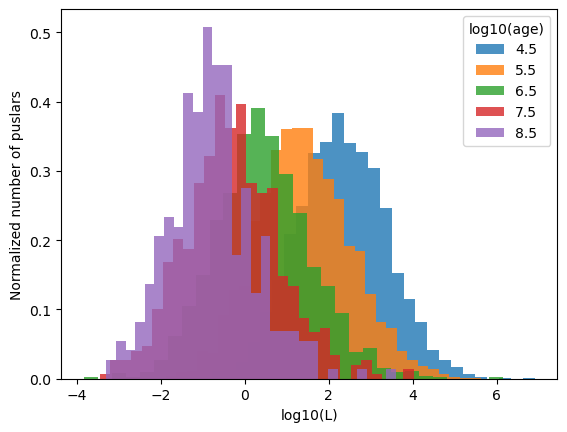

In [22]:
import matplotlib.pyplot as plt
plt.hist(np.log10(lum),bins=30,density=True,alpha=.8,label='4.5')
plt.hist(np.log10(lum2),bins=30,density=True,alpha=.8,label='5.5')
plt.hist(np.log10(lum3),bins=30,density=True,alpha=.8,label='6.5')
plt.hist(np.log10(lum4),bins=30,density=True,alpha=.8,label='7.5')
plt.hist(np.log10(lum5),bins=30,density=True,alpha=.8,label='8.5')
plt.xlabel('log10(L)')
plt.legend(title='log10(age)')
plt.ylabel("Normalized number of puslars")

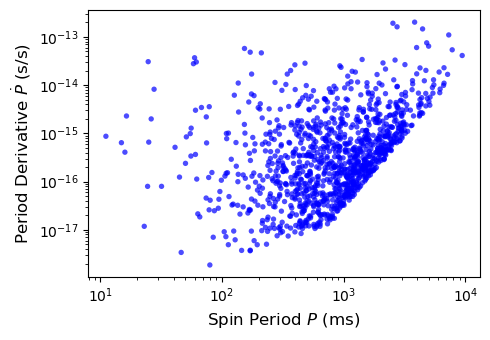

In [10]:
import matplotlib.pyplot as plt

# 1. Use 'psr' (the variable returned by your function) instead of 'pulsars'
active_p = p
active_pdot = pdot
#print(active_p)

#dead_p = [p.period for p in psr if p.dead]
#dead_pdot = [p.pdot for p in psr if p.dead]
#dead=[p.dead for p in psr]
#print(dead)
# 2. Initialize the plot
plt.figure(figsize=(5, 3.5))

# 3. Scatter plot active and dead populations
plt.scatter(active_p, active_pdot, color='blue', alpha=0.7, label='Active Pulsars', edgecolors='none', s=15)
#plt.scatter(dead_p, dead_pdot, color='blue', alpha=0.4, label='Dead Pulsars', edgecolors='none', s=15)

# 4. Set logarithmic scales
plt.xscale('log')
plt.yscale('log')
#plt.xlim(100,1000)
# 5. Add labels, title, and formatting
plt.xlabel('Spin Period $P$ (ms)', fontsize=12)
plt.ylabel('Period Derivative $\dot{P}$ (s/s)', fontsize=12)
#plt.title('Pulsar Population $P-\dot{P}$ Diagram', fontsize=14)
#plt.grid(True, which="both", ls="--", alpha=0.5)
#plt.legend(loc='upper left', fontsize=11)

# 6. Display the plot
plt.tight_layout()
plt.show()


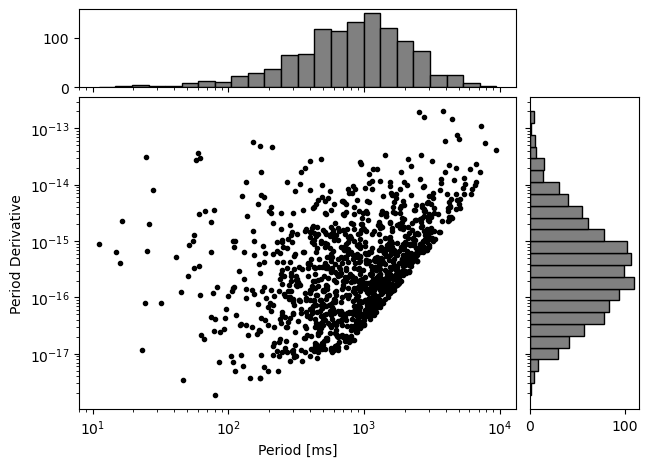

In [12]:
#making a histogram with scatter
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x",labelbottom=False)
    ax_histy.tick_params(axis="y",labelleft=False)
    ax.set_xlabel('Period [ms]') 
    ax.set_ylabel('Period Derivative')
    ax.set_xscale('log')
    ax.set_yscale('log')


    # the scatter plot:
    ax.scatter(x, y,color='k',marker='.')

    # now determine nice limits by hand:
    binx=(np.logspace(np.log10(x.min()), np.log10(x.max()), num=25))
    biny=(np.logspace(np.log10(y.min()), np.log10(y.max()), num=25))
    ax_histx.hist(x, ec="black",bins=binx,color='grey')
    ax_histy.hist(y, orientation='horizontal',ec="black",bins=biny,color='grey')
    
# Start with a square Figure.
fig = plt.figure(figsize=(7, 5))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
x=np.array(active_p)
y=np.array(active_pdot)
# Draw the scatter plot and marginals.
scatter_hist(x, y, ax, ax_histx, ax_histy)
plt.savefig('p-pdot.png');plt.show();plt.close()

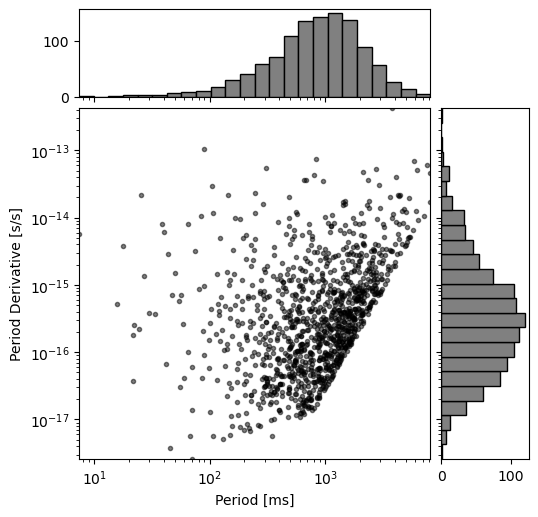

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# making a histogram with scatter
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    
    # 1. Apply log scales to the primary scatter plot axes
    ax.set_xlabel('Period [ms]')
    ax.set_ylabel('Period Derivative [s/s]')
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # 2. CRITICAL FIX: Explicitly set log scales on the unshared marginal axes
    ax_histx.set_yscale('linear')  # Keep histogram counts linear
    ax_histy.set_xscale('linear')  # Keep histogram counts linear
    
    # the scatter plot:
    ax.scatter(x, y, color='k', marker='.', alpha=0.5) # alpha helps see density
    
    # 3. CRITICAL FIX: Safe logspace bounding (handles extreme small/zero values safely)
    x_min, x_max = max(x.min(), 1e-3), x.max()
    y_min, y_max = max(y.min(), 1e-22), y.max()
    
    binx = np.logspace(np.log10(x_min), np.log10(x_max), num=25)
    biny = np.logspace(np.log10(y_min), np.log10(y_max), num=25)
    
    # 4. Draw histograms matching the logarithmic layout
    ax_histx.hist(x, ec="black", bins=binx, color='grey')
    ax_histy.hist(y, orientation='horizontal', ec="black", bins=biny, color='grey')
    
    # 5. Lock identical axis limits to eliminate white spaces or clipping
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

# Start with a square Figure.
fig = plt.figure(figsize=(6, 6)) # Bumped to 6x6 for axis label breathing room

# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.15, right=0.9, bottom=0.15, top=0.9,
                      wspace=0.05, hspace=0.05)

# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# Clean up input arrays from tracking loops
x = np.array(active_p)
y = np.array(active_pdot)

# Ensure data doesn't contain zeros/negatives which break log math
valid_data = (x > 0) & (y > 0)
x = x[valid_data]
y = y[valid_data]

# Draw the scatter plot and marginals.
scatter_hist(x, y, ax, ax_histx, ax_histy)

plt.savefig('p-pdot.png', dpi=300) # Higher DPI for publication quality
plt.show()
plt.close()